Cellule 1 : Importations et Configuration

In [32]:
# Importation des bibliothèques nécessaires
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import folium
import os
import webbrowser
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Configuration pour un affichage propre dans le Notebook
pd.set_option('display.max_columns', None)

Cellule 2 : 1. Compréhension et Exploration (EDA)

In [33]:
# Chargement du jeu de données
df = pd.read_csv("dataset/geo_stabilite_terrain_data.csv")

# Affichage des 10 premières lignes (sans print pour formatage HTML)
# Étape 1 : Analyser la structure
display(df.head(10))

# Informations sur les types de données et valeurs manquantes
print("--- Info du dataset ---")
df.info()

# Statistiques descriptives
print("--- Statistiques ---")
display(df.describe())

# Vérification des valeurs manquantes initiales
print("--- Valeurs manquantes par colonne ---")
print(df.isnull().sum())

,pente_pct,altitude_m,texture_sol,humidite_sol,distance_faille_km,couverture_vegetale,longitude,latitude,zone_id,stabilite_terrain,indice_geotech_labo
0,14.981605,640.304544,0.488496,42.206608,6.767225,0.707993,-6.258685,34.429771,427,Moyennement_stable,NaN
1,38.028572,845.545277,0.401887,26.103519,0.120083,0.267965,-6.548971,34.860529,344,MOY_STABLE,NaN
2,29.279758,622.540410,0.153691,15.356171,0.988193,0.204539,-6.202923,34.569859,507,moyennement stable,NaN
3,23.946339,522.707003,0.572607,7.113067,10.581034,0.526851,-5.632015,35.252465,341,Moyennement_stable,NaN
4,6.240746,622.013551,0.277013,34.043394,NaN,0.310989,-6.538227,35.193357,321,Moyennement_stable,NaN
5,6.239781,697.793645,0.921308,9.852120,NaN,0.616015,-6.314916,34.452766,484,Stable,NaN
6,2.323344,608.794813,0.583191,17.111005,11.044456,0.156145,-5.681898,35.403913,425,MOY_STABLE,NaN
7,34.647046,607.306504,0.592840,NaN,3.284669,0.639447,-5.582553,34.698492,456,moyennement stable,NaN
8,24.044600,473.641496,0.354925,27.576664,4.477373,0.304967,-6.008086,34.918672,484,Moyennement_stable,NaN
9,28.322903,480.677835,0.051989,29.023328,6.848611,0.050219,-5.692503,35.201520,364,Moyennement_stable,NaN


--- Info du dataset ---
<class 'pandas.DataFrame'>
RangeIndex: 1549 entries, 0 to 1548
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   pente_pct            1455 non-null   float64
 1   altitude_m           1501 non-null   float64
 2   texture_sol          1417 non-null   float64
 3   humidite_sol         1443 non-null   float64
 4   distance_faille_km   1486 non-null   float64
 5   couverture_vegetale  1455 non-null   float64
 6   longitude            1549 non-null   float64
 7   latitude             1549 non-null   float64
 8   zone_id              1549 non-null   int64  
 9   stabilite_terrain    1548 non-null   str    
 10  indice_geotech_labo  156 non-null    float64
dtypes: float64(9), int64(1), str(1)
memory usage: 133.2 KB
--- Statistiques ---


,pente_pct,altitude_m,texture_sol,humidite_sol,distance_faille_km,couverture_vegetale,longitude,latitude,zone_id,indice_geotech_labo
count,1455.000000,1501.000000,1417.000000,1443.000000,1486.000000,1455.000000,1549.000000,1549.000000,1549.000000,156.000000
mean,19.914196,608.526967,0.490783,24.753442,5.876987,0.488085,-5.939485,34.995105,362.592640,0.551224
std,11.727497,176.181677,0.287108,11.592068,3.414436,0.252860,0.373466,0.351013,92.572292,0.134978
min,0.185281,70.730046,0.000031,5.156735,0.052880,0.050048,-6.599687,34.400189,200.000000,0.171521
25%,9.516407,486.732589,0.237479,14.741637,2.974439,0.276923,-6.264394,34.688642,283.000000,0.466280
50%,20.136691,606.882839,0.483181,24.640791,5.804080,0.479078,-5.933843,34.979046,362.000000,0.538526
75%,29.992246,724.725352,0.739469,34.700119,8.769188,0.697907,-5.615704,35.309189,442.000000,0.636614
max,39.988707,1174.759362,0.999558,44.978427,11.990527,0.948756,-5.300425,35.599202,519.000000,0.886169


--- Valeurs manquantes par colonne ---
pente_pct                94
altitude_m               48
texture_sol             132
humidite_sol            106
distance_faille_km       63
couverture_vegetale      94
longitude                 0
latitude                  0
zone_id                   0
stabilite_terrain         1
indice_geotech_labo    1393
dtype: int64


Cellule 3 : 2. Visualisation (Avant Prétraitement)

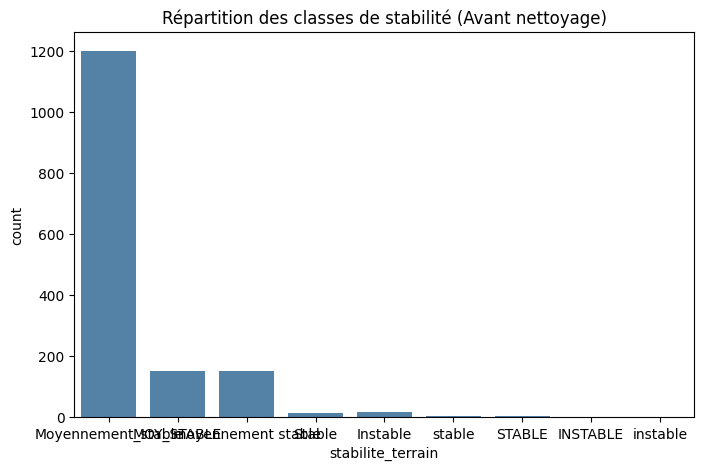

In [34]:
# Visualisation de la distribution de la cible pour détecter les déséquilibres
plt.figure(figsize=(8, 5))
sns.countplot(x='stabilite_terrain', data=df, color='steelblue')
plt.title("Répartition des classes de stabilité (Avant nettoyage)")
plt.show()

Cellule 4 : 3. Prétraitement des données

In [35]:
# --- Harmonisation des modalités ---
df["stabilite_terrain"] = df["stabilite_terrain"].str.lower().str.strip()
df["stabilite_terrain"] = df["stabilite_terrain"].replace({
    "moyennement_stable": "moyen",
    "moyennement stable": "moyen",
    "moy_stable": "moyen"
})

# --- Traitement des valeurs manquantes et colonnes ---
# Justification : suppression d'indice_geotech_labo car trop de données manquantes
df.drop(columns="indice_geotech_labo", inplace=True, errors='ignore')

# Imputation par moyenne/mode
df["pente_pct"] = df["pente_pct"].fillna(df["pente_pct"].mean())
df["altitude_m"] = df["altitude_m"].fillna(df["altitude_m"].mode()[0])
df["texture_sol"] = df["texture_sol"].fillna(df["texture_sol"].mean())
df["humidite_sol"] = df["humidite_sol"].fillna(df["humidite_sol"].mean())
df["distance_faille_km"] = df["distance_faille_km"].fillna(df["distance_faille_km"].mean())
df["couverture_vegetale"] = df["couverture_vegetale"].fillna(df["couverture_vegetale"].mean())

# Suppression des lignes résiduelles problématiques
df = df.dropna(subset=["stabilite_terrain"])
df = df.dropna(how = "any")

# Détection et suppression des doublons
df = df.drop_duplicates()

print("Prétraitement terminé. Valeurs manquantes restantes :", df.isnull().sum().sum())

Prétraitement terminé. Valeurs manquantes restantes : 0


Cellule 5 : 4. Modélisation (Random Forest)

In [36]:
# --- Étape 4 : Modélisation ---

# Sélection des features (Variables spatiales exclues du modèle selon la règle)
features = ["pente_pct", "altitude_m", "texture_sol", "humidite_sol", "distance_faille_km", "couverture_vegetale"]
X = df[features]
Y = df["stabilite_terrain"]

# Standardisation des données numériques
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Séparation Train/Test (Même split pour tous les futurs modèles)
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.25, random_state=42)

# Implémentation du Random Forest (Exemple optimisé)
model_rf = RandomForestClassifier()
model_rf.fit(X_train, Y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

Cellule 6 : 5. Évaluation et Visualisation

--- Rapport de Performance ---
Accuracy : 96.64%
              precision    recall  f1-score   support

    instable       0.00      0.00      0.00         6
       moyen       0.97      1.00      0.98       374
      stable       0.00      0.00      0.00         7

    accuracy                           0.97       387
   macro avg       0.32      0.33      0.33       387
weighted avg       0.93      0.97      0.95       387



c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\ACER\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(averag

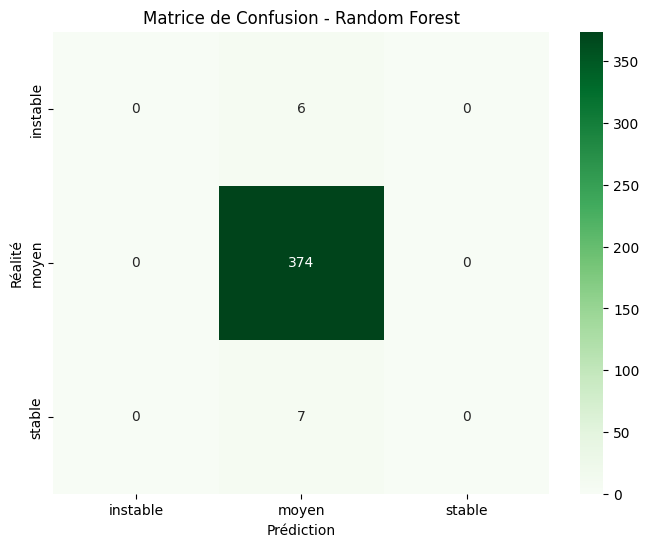

In [37]:
# --- Étape 5 & 6 : Évaluation et Analyse ---

Y_pred = model_rf.predict(X_test)

print("--- Rapport de Performance ---")
print(f"Accuracy : {accuracy_score(Y_test, Y_pred):.2%}")
print(classification_report(Y_test, Y_pred))

# Matrice de Confusion
conf_matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

Cellule 7 : d'Optimisation des Hyperparamètres

In [ ]:
from sklearn.model_selection import GridSearchCV
# 1. Définition de la grille de paramètres à tester
param_grid = {
    'n_estimators': [100, 200, 300],      # Nombre d'arbres
    'max_depth': [None, 10, 20, 30],      # Profondeur maximale
    'min_samples_split': [2, 5, 10],      # Min samples pour diviser un noeud
    'max_features': ['sqrt', 'log2'],     # Nombre de features à chaque split
    'criterion': ['gini', 'entropy']      # Fonction de mesure de qualité
}
# 2. Initialisation du modèle de base
rf_base = RandomForestClassifier(random_state=42, class_weight='balanced'   )
# 3. Configuration de la recherche (Cross-Validation à 5 plis)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2, scoring='accuracy')
# 4. Exécution de l'optimisation sur les données d'entraînement
print("Recherche des meilleurs paramètres en cours...")
grid_search.fit(X_train, Y_train)
# 5. Affichage des résultats
print("\n--- Meilleurs Paramètres Trouvés ---")
print(grid_search.best_params_)
# On récupère le meilleur modèle pour la suite
model_rf = grid_search.best_estimator_
Y_pred = model_rf.predict(X_test)


Recherche des meilleurs paramètres en cours...
Fitting 5 folds for each of 144 candidates, totalling 720 fits

--- Meilleurs Paramètres Trouvés ---
{'criterion': 'entropy', 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 100}


Cellule 8 :  Évaluation et Visualisation Finale

--- Rapport de Performance ---
Accuracy : 97.93%
              precision    recall  f1-score   support

    instable       1.00      0.67      0.80         6
       moyen       0.98      1.00      0.99       374
      stable       1.00      0.14      0.25         7

    accuracy                           0.98       387
   macro avg       0.99      0.60      0.68       387
weighted avg       0.98      0.98      0.97       387



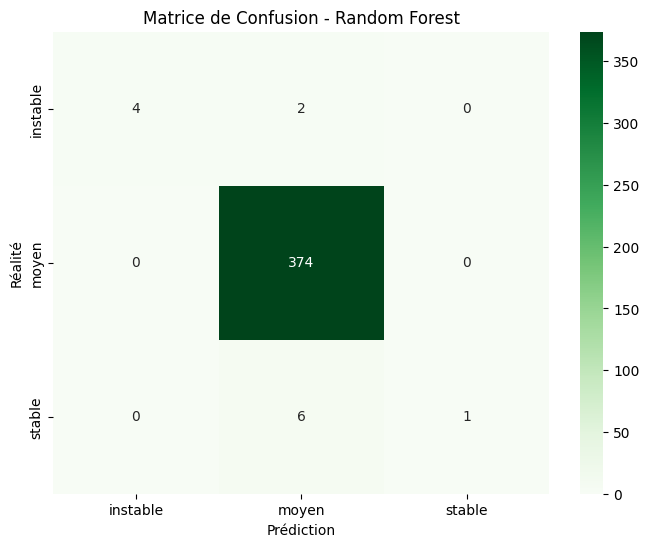

In [39]:
# --- Étape 5 & 6 : Évaluation et Analyse ---

print("--- Rapport de Performance ---")
print(f"Accuracy : {accuracy_score(Y_test, Y_pred):.2%}")
print(classification_report(Y_test, Y_pred))

# Matrice de Confusion
conf_matrix = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Greens',
            xticklabels=model_rf.classes_, yticklabels=model_rf.classes_)
plt.xlabel('Prédiction')
plt.ylabel('Réalité')
plt.title('Matrice de Confusion - Random Forest')
plt.show()

Cellule 9 : Cartographie Spatiale

In [40]:
# Utilisation des coordonnées uniquement pour la visualisation
df["prediction_rf"] = model_rf.predict(X_scaled)

# Création de la carte
m = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=8)

# Dictionnaire de couleurs
colors = {"instable": "red", "moyen": "orange", "stable": "green"}

# Ajout des points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=5,
        color=colors.get(row["prediction_rf"], "gray"),
        fill=True,
        popup=f"ID: {row['zone_id']} | Prédit: {row['prediction_rf']}"
    ).add_to(m)

m.save("carte_stabilite.html")
print("Carte générée avec succès.")
webbrowser.open(os.path.abspath("carte_stabilite.html"))

Carte générée avec succès.


True